---
# ══════════════════════════════════════════════════════
# SECTION: DATA
# ══════════════════════════════════════════════════════

In [1]:
##########################################################
#                 DATA RETRIEVAL VIA STEAM API
#
# NOTE:
# Running this section may take a significant amount of
# time due to API rate limits and the large number of
# requests required. A delay mechanism is implemented to
# prevent overloading the Steam API.
#
# This dataset extraction covers 100 Steam games in a
# single batch. Previously this was split into two
# batches of 50 due to:
#
# - API timeouts
# - Large-scale data volume
# - Approximately 40% of raw data being unusable after
#   preprocessing
#
# The two batches have been merged into one unified
# pipeline to simplify the workflow and eliminate the
# duplicate reviews that arose from running two separate
# scripts appending to the same output file.
#
# Please refer to the project report for full details.
##########################################################

##########################################################
#                 STEAM API LIMITATIONS
#               AND IMPLEMENTED WORKAROUNDS
#
# The Steam Review API is a powerful publicly available
# data source, but it imposes several constraints that
# affect large-scale data extraction.
# The following limitations were encountered and addressed
# in this pipeline:
#
# 1. REVIEW LIMIT PER REQUEST
# ------------------------------------------------
# Each API request returns a maximum of 100 reviews.
# Therefore, pagination and multiple requests are
# required to collect sufficient data per game.
#
#
# 2. PAGINATION SYSTEM (CURSOR-BASED)
# ------------------------------------------------
# The API uses a cursor to navigate between pages of
# reviews. This ensures sequential access to review
# data without duplication.
#
#
# 3. RATE LIMITING
# ------------------------------------------------
# Excessive request frequency can lead to throttling
# or failed responses from the Steam servers.
#
# To mitigate this, controlled delays were introduced
# between requests using:
#
# time.sleep()
#
#
# 4. LIMITED FILTERING CAPABILITIES
# ------------------------------------------------
# The API only supports basic filtering options such as:
#
# - Language selection (English only)
# - Recent reviews
# - Purchase type (Steam only)
#
# 5. REVIEW IMBALANCE ACROSS GAMES
# ------------------------------------------------
# Some games contain significantly more positive reviews
# than negative reviews, making it necessary to enforce
# class balancing during extraction.
#
#
# 6. MISSING OR EMPTY REVIEWS
# ------------------------------------------------
# Certain API responses contain empty review fields,
# which are removed during processing to maintain
# dataset quality.
#
# 7. DUPLICATE REVIEWS
# ------------------------------------------------
# Appending to the same CSV across multiple runs or
# sessions can introduce duplicate reviews. To prevent
# this, save_to_csv() checks existing review_id values
# (Steam's recommendationid) before writing, and
# balance_dataset() deduplicates by review text before
# sampling.
##########################################################

##########################################################
#                 EXTRACTED DATA FEATURES
#
# Each review extracted from the Steam API contains:
#
# 1. review_id      → Steam's unique review identifier
#                      (recommendationid field from API)
# 2. app_id         → Unique game identifier
# 3. review_text    → User-generated review content
# 4. sentiment      → Binary label (1 = positive,
#                      0 = negative via voted_up field)
# 5. helpful_score  → Community weighted usefulness score
#
# NOTE:
# The timestamp field was intentionally removed as it is
# not required for sentiment classification tasks.
#
# The helpful_score is retained for potential future use
# in quality filtering or analysis.
##########################################################

##########################################################
#                 EXTRACTION PROCESS
#
# The extraction pipeline follows a structured loop-based
# approach:
#
# 1. Iterate through 100 selected Steam App IDs
# 2. Send API request for review data
# 3. Extract relevant fields from JSON response
# 4. Store valid reviews into structured dictionaries
# 5. Use cursor-based pagination to access additional pages
# 6. Repeat until:
#    - Target number of positive/negative reviews is met
#    - No more review pages exist
#
# This ensures large-scale, controlled, and structured
# data collection for  our NLP model training.
##########################################################

##########################################################
#                 FINAL OUTPUT STRUCTURE
#
# The extracted dataset is stored in CSV format:
#
# steam_reviews_final.csv
#
# Each record contains:
#
# review_id | app_id | review_text | sentiment | helpful_score
#
# This dataset is later:
# - Cleaned (noise removal, filtering)
# - Balanced (equal class distribution)
# - Used for model training:
#   * Naive Bayes (TF-IDF)
#   * LSTM (sequence modeling)
#   * BERT (transformer-based classification)
##########################################################

# -*- coding: utf-8 -*-
import sys
import io
import requests
import time
import csv
import os
import pandas as pd
from typing import List, Dict

# ========== FIX UTF-8 DISPLAY IN COLAB ==========
# Force stdout to use UTF-8 (fixes â™¥ garbage in console output)
if hasattr(sys.stdout, 'buffer'):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8')

# ========== CONFIGURATION ==========
# 100 verified Steam App IDs (mix of paid and free games with many negative reviews)
# Originally extracted in two batches of 50. Merged here into a single pipeline
# to prevent duplicate reviews from repeated CSV appending across separate runs.
APP_IDS = [
    # --- Batch 1 (original 50) ---
    252490, 1245620, 1086940, 814380, 1966720, 1003590, 1551360, 582010, 1091500,
    1174180, 271590, 359550, 381210, 578080, 730, 570, 1172470, 230410, 236390,
    105600, 413150, 892970, 526870, 1145360, 1794680, 550, 322170, 431960, 440,
    218620, 394360, 377160, 289070, 307690, 374320, 637090, 444090, 264710, 362890,
    282140, 601150, 1850570, 1599340, 1332010, 1468270, 1250410, 1361210, 1284190,
    427520,

    # --- Batch 2 (additional 50) ---
    489830, 292030, 620, 400, 220, 546560, 4000, 252950, 1085660, 945360,
    227300, 270880, 782330, 379720, 8870, 346110, 242760, 1326470, 367520, 504230,
    588650, 268910, 848450, 1687950, 12210, 20920, 20900, 570940, 335300, 22380,
    22370, 1030840, 1030830, 1659040, 863550, 870780, 412020, 286690, 1888930,
    205100, 403640, 883710, 2050650, 524220, 646570, 812140, 552520, 1426210
]

# Remove any accidental duplicates across the two batches
APP_IDS = list(dict.fromkeys(APP_IDS))

TARGET_POSITIVE = 500      # target positive reviews per game
TARGET_NEGATIVE = 500      # target negative reviews per game
REVIEWS_PER_PAGE = 100     # Steam API max per request
LANGUAGE = "english"
OUTPUT_CSV = "steam_reviews_final.csv"
REQUEST_DELAY = 0          # seconds between page requests (increase if throttled)

# ========== FUNCTIONS ==========

def fetch_reviews_page(app_id: int, cursor: str = "*") -> dict:
    """Fetch one page of reviews from Steam API with proper UTF-8 handling."""
    url = f"https://store.steampowered.com/appreviews/{app_id}"
    params = {
        "json": 1,
        "language": LANGUAGE,
        "num_per_page": REVIEWS_PER_PAGE,
        "cursor": cursor,
        "filter": "recent",
        "purchase_type": "steam"
    }
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Accept-Charset': 'utf-8'
    }
    try:
        response = requests.get(url, params=params, headers=headers, timeout=10)
        response.encoding = 'utf-8'  # Force UTF-8 decoding
        if response.status_code == 200:
            return response.json()
        else:
            print(f"  Error {response.status_code} for app {app_id}")
            return None
    except Exception as e:
        print(f"  Request failed: {e}")
        return None


def collect_reviews_for_app(app_id: int, target_pos: int, target_neg: int) -> List[dict]:
    """Collect reviews for a single game until targets are met or no more reviews."""
    print(f"\n--- Starting App ID: {app_id} ---")
    collected = []
    pos_count = 0
    neg_count = 0
    cursor = "*"
    max_loops = 1000  # Allow deep pagination

    for loop in range(max_loops):
        if pos_count >= target_pos and neg_count >= target_neg:
            break

        print(f"  Loop {loop+1}: pos {pos_count}/{target_pos}, neg {neg_count}/{target_neg}")

        data = fetch_reviews_page(app_id, cursor)
        if not data or "reviews" not in data or not data["reviews"]:
            print("  No more reviews found.")
            break

        for review in data["reviews"]:
            text = review.get("review", "").strip()
            if not text:
                continue
            recommended = review.get("voted_up", False)

            # Only collect if we still need this sentiment class
            if recommended and pos_count < target_pos:
                collected.append({
                    "review_id": review.get("recommendationid", ""),
                    "app_id": app_id,
                    "review_text": text,
                    "sentiment": 1,
                    "helpful_score": review.get("weighted_vote_score", 0),
                })
                pos_count += 1
            elif not recommended and neg_count < target_neg:
                collected.append({
                    "review_id": review.get("recommendationid", ""),
                    "app_id": app_id,
                    "review_text": text,
                    "sentiment": 0,
                    "helpful_score": review.get("weighted_vote_score", 0),
                })
                neg_count += 1

        # Get cursor for next page
        cursor = data.get("cursor", "")
        if not cursor:
            print("  No cursor for next page.")
            break

        time.sleep(REQUEST_DELAY)

    print(f"  Finished app {app_id}: {pos_count} pos, {neg_count} neg")
    return collected


def save_to_csv(all_reviews: List[dict], filename: str):
    """
    Append reviews to CSV with UTF-8-sig encoding (Excel-friendly).

    Deduplication check: before writing, any review whose review_id already
    exists in the file is skipped. Using review_id (Steam's recommendationid)
    is more reliable than text matching, as two users could theoretically
    write identical short reviews. This prevents duplicate rows from
    accumulating if the script is re-run or interrupted and restarted.
    """
    file_exists = os.path.isfile(filename)
    existing_texts = set()

    # Load existing review IDs to avoid writing duplicates
    if file_exists:
        existing = pd.read_csv(filename, encoding='utf-8-sig')
        existing_texts = set(existing['review_id'].astype(str).tolist())

    # Filter out reviews already present in the file
    new_reviews = [r for r in all_reviews if str(r['review_id']) not in existing_texts]
    skipped = len(all_reviews) - len(new_reviews)
    if skipped > 0:
        print(f"  Skipped {skipped} duplicate reviews before saving.")

    with open(filename, 'a', newline='', encoding='utf-8-sig') as f:
        writer = csv.DictWriter(f, fieldnames=["review_id", "app_id", "review_text", "sentiment", "helpful_score"])
        if not file_exists:
            writer.writeheader()
        writer.writerows(new_reviews)


def balance_dataset(csv_path: str, output_path: str, target_total: int = 50000):
    """
    Balance the dataset to exactly target_total (half positive, half negative).

    Deduplication is applied before sampling to ensure the balanced output
    contains only unique reviews. This prevents inflated model performance
    caused by identical reviews appearing in both train and test splits.
    """
    df = pd.read_csv(csv_path, encoding='utf-8-sig')

    # Remove duplicate review texts before balancing
    before = len(df)
    df = df.drop_duplicates(subset=['review_text'])
    print(f"  Duplicates removed before balancing: {before - len(df)}")

    pos = df[df['sentiment'] == 1]
    neg = df[df['sentiment'] == 0]
    min_count = min(len(pos), len(neg))
    desired = target_total // 2
    sample_size = min(min_count, desired)

    pos_sample = pos.sample(sample_size, random_state=42)
    neg_sample = neg.sample(sample_size, random_state=42)
    balanced = pd.concat([pos_sample, neg_sample]).sample(frac=1, random_state=42)
    balanced.to_csv(output_path, index=False, encoding='utf-8-sig')

    print(f"\n=== Balanced dataset saved to {output_path} ===")
    print(f"Size: {len(balanced)} reviews ({sample_size} positive, {sample_size} negative)")
    return balanced


# ========== MAIN ==========
def main():
    print(f"Starting extraction for {len(APP_IDS)} games...")
    all_reviews = []

    for i, app_id in enumerate(APP_IDS):
        print(f"\n--- Game {i+1}/{len(APP_IDS)} ---")
        reviews = collect_reviews_for_app(app_id, TARGET_POSITIVE, TARGET_NEGATIVE)
        if reviews:
            save_to_csv(reviews, OUTPUT_CSV)
            all_reviews.extend(reviews)
        else:
            print(f"  No reviews collected for app {app_id}. Skipping.")
        time.sleep(2)  # Delay between games to avoid throttling

    print(f"\nRaw collection complete. Total reviews collected: {len(all_reviews)}")
    pos_total = sum(1 for r in all_reviews if r['sentiment'] == 1)
    neg_total = len(all_reviews) - pos_total
    print(f"Raw positives: {pos_total}, Raw negatives: {neg_total}")

    if len(all_reviews) > 0:
        balance_dataset(OUTPUT_CSV, "steam_reviews_balanced_50k.csv", target_total=50000)
    else:
        print("No reviews collected at all. Check your internet/API.")


if __name__ == "__main__":
    main()


Streaming output truncated to the last 5000 lines.
  Loop 198: pos 500/500, neg 329/500
  Loop 199: pos 500/500, neg 333/500
  Loop 200: pos 500/500, neg 335/500
  Loop 201: pos 500/500, neg 335/500
  Loop 202: pos 500/500, neg 340/500
  Loop 203: pos 500/500, neg 341/500
  Loop 204: pos 500/500, neg 343/500
  Loop 205: pos 500/500, neg 346/500
  Loop 206: pos 500/500, neg 348/500
  Loop 207: pos 500/500, neg 349/500
  Loop 208: pos 500/500, neg 353/500
  Loop 209: pos 500/500, neg 361/500
  Loop 210: pos 500/500, neg 364/500
  Loop 211: pos 500/500, neg 369/500
  Loop 212: pos 500/500, neg 370/500
  Loop 213: pos 500/500, neg 371/500
  Loop 214: pos 500/500, neg 371/500
  Loop 215: pos 500/500, neg 374/500
  Loop 216: pos 500/500, neg 375/500
  Loop 217: pos 500/500, neg 377/500
  Loop 218: pos 500/500, neg 381/500
  Loop 219: pos 500/500, neg 383/500
  Loop 220: pos 500/500, neg 387/500
  Loop 221: pos 500/500, neg 391/500
  Loop 222: pos 500/500, neg 396/500
  Loop 223: pos 500/500,

In [3]:
##########################################################
#                 DATASET CLEANING / PREPROCESSING
#
# This section involves cleaning the dataset extracted
# and merged from the Steam API. Full methodological
# details are provided in the project report.
#
# The dataset is prepared for three NLP model families:
#
# 1. Naive Bayes (Traditional ML)
# 2. LSTM (Deep Learning)
# 3. BERT (Transformer Models)
#
# The raw Steam review dataset contains real-world user
# generated content, which introduces significant noise
# that must be removed before model training.
#
# The following preprocessing steps are applied:
#
# - Corrupted UTF-8 encoding removal (e.g., ♥, â™¥)
# - URL and hyperlink removal (spam / non-informative text)
# - Language filtering using LangDetect (English only)
# - Emoji removal to ensure consistent tokenisation
# - Spam filtering (repeated characters, symbols, unicode spam)
# - Removal of empty or whitespace-only reviews
#
# IMPORTANT NOTE ON LANGUAGE DETECTION:
# Steam's built-in language metadata is not fully reliable.
# Users may have their Steam client set to English while
# writing reviews in another language (e.g., Chinese).
#
# Therefore, LangDetect is used to verify actual review
# language content rather than relying on Steam metadata.
#
# Example issue:
# - Steam labels review as "English" due to client settings
# - Actual review text may be Chinese or mixed language
#
# LangDetect ensures only true English text is retained,
# improving dataset quality and model performance consistency.
##########################################################

!pip install emoji langdetect

import pandas as pd
import re
import emoji
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0

# =========================
# 1. LOAD DATASET
# =========================
file_path = "/content/steam_reviews_final.csv"

df = pd.read_csv(file_path, encoding="utf-8-sig")

initial = len(df)

print("Initial dataset:", initial)

# Ensure all review text values are strings
df["review_text"] = df["review_text"].astype(str)

# =========================
# 4. REMOVE CORRUPTED ♥ ENCODING
# =========================
before = len(df)

df = df[
    ~df["review_text"].str.contains(
        r"♥|â™¥",
        regex=True,
        na=False
    )
]

print("Encoding cleanup removed:", before - len(df))

# =========================
# 5. REMOVE LINKS
# =========================
before = len(df)

df = df[
    ~df["review_text"].str.contains(
        r"http\S+|www\.\S+",
        regex=True,
        na=False
    )
]

print("Link removal removed:", before - len(df))

# =========================
# 6. KEEP ONLY ENGLISH (LANG DETECT)
# =========================
def is_english(text):
    try:
        return detect(text) == "en"
    except:
        return False

before = len(df)

df = df[df["review_text"].apply(is_english)]

print("Language filtering removed:", before - len(df))

# =========================
# 7. REMOVE EMOJIS
# =========================
def has_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

before = len(df)

df = df[~df["review_text"].apply(has_emoji)]

print("Emoji removal removed:", before - len(df))

# =========================
# 8. SPAM FILTER
# =========================
spam_patterns = [
    r"(.)\1{4,}",
    r"[⭐★☆]{3,}",
    r"[⣿]{2,}",
    r"^[^\w\s]{3,}$"
]

spam_regex = re.compile("|".join(spam_patterns))

before = len(df)

df = df[
    ~df["review_text"].str.contains(
        spam_regex,
        regex=True,
        na=False
    )
]

print("Spam filtering removed:", before - len(df))

# =========================
# 9. REMOVE EMPTY ROWS
# =========================
before = len(df)

df = df[df["review_text"].str.strip().astype(bool)]

print("Empty rows removed:", before - len(df))

# =========================
# 10. RESET INDEX + ADD REVIEW ID
# =========================
df = df.reset_index(drop=True)

# Remove existing review_id column if it already exists
if "review_id" in df.columns:
    df = df.drop(columns=["review_id"])

df.insert(0, "review_id", range(1, len(df) + 1))

# =========================
# 11. SAVE FINAL FILE
# =========================
output_path = "/content/steam_reviews_final_clean.csv"

df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("DONE ✔ Dataset fully cleaned")
print("Final rows:", len(df))
print("Total removed:", initial - len(df))

Initial dataset: 94922
Encoding cleanup removed: 6467
Link removal removed: 216
Language filtering removed: 21950
Emoji removal removed: 538


/tmp/ipykernel_3639/148423011.py:138: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df["review_text"].str.contains(


Spam filtering removed: 1183
Empty rows removed: 0
DONE ✔ Dataset fully cleaned
Final rows: 64568
Total removed: 30354


In [ ]:
from google.colab import files
files.download("/content/steam_reviews_cleaned.csv")

In [4]:
##########################################################
#    With our data cleaned, we Proceeded with
#   balancing which was done here
##########################################################
##########################################################
                 # DATA BALANCING PART 1
# After the review extraction process was completed,
# the dataset was loaded into a pandas DataFrame for
# preprocessing and balancing.
#
# The purpose of this stage is to ensure that the
# dataset contains an equal number of:
#
# - Positive Reviews
# - Negative Reviews
#
# Balanced datasets are important in Machine Learning
# because unbalanced data may bias the AI model toward
# the majority class.

                 # DATA BALANCING PART 2
# The dataset was separated into two groups using
# the sentiment column:
#
# - sentiment = 1 → Positive Reviews
# - sentiment = 0 → Negative Reviews
#
# This allowed the program to independently count
# and process each sentiment category.
#
# The original review totals for both classes were
# then displayed to determine whether balancing
# was required.

                 # DATA BALANCING PART 3
# Since the dataset may contain more positive
# reviews than negative reviews (or vice versa),
# random sampling was used to safely select an
# equal number of reviews from both classes.
#
# The target size was determined using:
#
# min(30000, len(pos), len(neg))
#
# This prevents sampling errors by ensuring that
# the program never attempts to sample more
# reviews than are available in either class.
#
# Random sampling improves fairness and reduces
# dataset bias during Machine Learning training.

                 # DATA BALANCING PART 4
# Once the positive and negative samples were
# selected, both groups were merged together
# into a single balanced dataset.
#
# The dataset was then shuffled randomly to
# ensure that positive and negative reviews
# are mixed evenly throughout the file.
#
# Shuffling prevents the AI model from learning
# patterns based on review ordering.

                 # DATA BALANCING PART 5
# After balancing and shuffling, new review IDs
# were assigned sequentially to ensure that:
#
# - All review IDs are unique
# - No duplicated IDs exist
# - The dataset remains properly structured
#
# Finally, the completed balanced dataset was
# exported into a new CSV file:
#
# steam_reviews_60k_balanced.csv
#
# The final dataset contains:
#
# - 30 000 Positive Reviews
# - 30 000 Negative Reviews
#
# giving a total of 60 000 balanced reviews
# ready for Machine Learning and Sentiment
# Analysis tasks.

##########################################################
import pandas as pd

# =========================
# 1. LOAD CLEAN DATASET
# =========================
file_path = "/content/steam_reviews_final_clean.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# =========================
# 2. SPLIT BY SENTIMENT
# =========================
pos = df[df["sentiment"] == 1]
neg = df[df["sentiment"] == 0]

print("Original counts:")
print("Positive:", len(pos))
print("Negative:", len(neg))

# =========================
# 3. SAFE SAMPLING (avoid errors)
# =========================
target = min(30000, len(pos), len(neg))

pos_sample = pos.sample(n=target, random_state=42)
neg_sample = neg.sample(n=target, random_state=42)

# =========================
# 4. MERGE + SHUFFLE
# =========================
balanced = pd.concat([pos_sample, neg_sample])
balanced = balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# =========================
# 5. FIX / REASSIGN REVIEW IDs
# =========================
balanced["review_id"] = range(1, len(balanced) + 1)

# =========================
# 6. SAVE FINAL DATASET
# =========================
output_path = "/content/steam_reviews_60k_balanced.csv"
balanced.to_csv(output_path, index=False, encoding="utf-8-sig")

# =========================
# 7. FINAL OUTPUT
# =========================
print("DONE ✔ Balanced dataset created")
print("Final size:", len(balanced))
print("Each class:", target)

Original counts:
Positive: 30805
Negative: 33763
DONE ✔ Balanced dataset created
Final size: 60000
Each class: 30000


In [6]:
##########################################################
#                 DATASET SPLITTING (TRAIN/TEST)
#
# After balancing and cleaning the Steam review dataset,
# the data is prepared for Machine Learning training and
# evaluation across three NLP model generations:
#
# 1. Naive Bayes (Traditional ML)
# 2. LSTM (Deep Learning)
# 3. BERT (Transformer-Based Models)
#
# To ensure fair evaluation, the dataset is split into
# training and testing sets using a stratified approach.
#
##########################################################

                 # DATASET SPLITTING PART 1
# The final balanced dataset is loaded from CSV format.
#
# This dataset contains:
# - review_text
# - sentiment (binary label: 1 = positive, 0 = negative)
#
# The dataset is already balanced to ensure equal class
# distribution before model training.

                 # DATASET SPLITTING PART 2
# A 70/30 train-test split is performed:
#
# - 70% of data → Training set
# - 30% of data → Testing set
#
# Stratified sampling is used to ensure that both the
# training and test sets maintain the same class
# distribution as the original dataset.
#
# This is critical for unbiased evaluation across all
# NLP models.

                 # DATASET SPLITTING PART 3
# After splitting, both datasets are re-indexed and
# assigned new sequential review IDs to maintain a
# clean structure.
#
# This ensures:
# - No duplicate IDs
# - Consistent dataset formatting
# - Easy traceability during evaluation

                 # DATASET SPLITTING PART 4
# The test dataset is then separated into two versions:
#
# 1. Test set WITH sentiment labels
#    → Used for evaluating model performance
#
# 2. Test set WITHOUT sentiment labels
#    → Used for simulating real-world predictions
#
# This allows both:
# - Supervised evaluation (accuracy, F1-score)
# - Unlabeled inference testing

                 # DATASET SPLITTING PART 5
# Final datasets are exported as CSV files:
#
# - steam_reviews_train.csv
# - steam_reviews_test_WITH_SENTIMENT.csv
# - steam_reviews_test_NO_SENTIMENT.csv
#
# These datasets are then used in the model training
# and evaluation pipeline for:
#
# - Naive Bayes classification (TF-IDF features)
# - LSTM sequence modeling
# - BERT transformer-based classification
#
##########################################################
import pandas as pd
from sklearn.model_selection import train_test_split

# =========================
# 1. LOAD BALANCED DATASET
# =========================
file_path = "/content/steam_reviews_60k_balanced.csv"
df = pd.read_csv(file_path, encoding="utf-8-sig")

# =========================
# 2. SPLIT (70 / 30)
# =========================
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["sentiment"]
)

# =========================
# 3. RESET INDEX + IDS
# =========================
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df["review_id"] = range(1, len(train_df) + 1)
test_df["review_id"] = range(1, len(test_df) + 1)

# =========================
# 4. CREATE TEST SET WITHOUT SENTIMENT
# =========================
test_no_sentiment = test_df.drop(columns=["sentiment"])

# =========================
# 5. SAVE FILES
# =========================
train_df.to_csv("/content/steam_reviews_train_FINAL.csv", index=False, encoding="utf-8-sig")

test_df.to_csv(
    "/content/steam_reviews_test_WITH_SENTIMENT_FINAL.csv",
    index=False,
    encoding="utf-8-sig"
)

test_no_sentiment.to_csv(
    "/content/steam_reviews_test_NO_SENTIMENT_FINAL.csv",
    index=False,
    encoding="utf-8-sig"
)

# =========================
# 6. OUTPUT INFO
# =========================
print("DONE ✔ Dataset split complete")
print("Train size:", len(train_df))
print("Test size:", len(test_df))

DONE ✔ Dataset split complete
Train size: 42000
Test size: 18000


In [ ]:
##########################################################
#        Downloading all of our Ready CSVs.
##########################################################
from google.colab import files

files.download("/content/steam_reviews_train.csv")
files.download("/content/steam_reviews_test_WITH_SENTIMENT.csv")
files.download("/content/steam_reviews_test_NO_SENTIMENT.csv")
files.download("/content/steam_reviews_final_clean.csv")

---
# ══════════════════════════════════════════════════════
# SECTION: NAIVE BAYES
# ══════════════════════════════════════════════════════

# COMP316 – Naive Bayes Sentiment Classifier
**Steam Reviews Dataset**



## 1. Install & Import

In [ ]:
##########################################################
#                      1. INSTALL & IMPORTS
#
# Core libraries:
#   pandas        → data loading and manipulation
#   numpy         → numerical operations
#   re            → regular expressions for text cleaning
#   time          → training duration tracking
#   matplotlib    → confusion matrix and feature plots
#   seaborn       → confusion matrix heatmap styling
#
# NLTK:
#   stopwords     → common English words to remove
#                   (e.g. 'the', 'is', 'and')
#   PorterStemmer → reduces words to their root form
#                   (e.g. 'playing' → 'play')
#
# Scikit-learn:
#   TfidfVectorizer    → converts cleaned text into
#                        TF-IDF feature vectors
#   MultinomialNB      → Naive Bayes classifier
#   accuracy_score etc → evaluation metrics
##########################################################
!pip install nltk scikit-learn pandas matplotlib seaborn -q

from google.colab import drive
drive.mount('/content/drive')

import os
path = '/content/drive/MyDrive/COMP316_Project_CleanedData'
print(os.listdir(path))

import pandas as pd
import numpy as np
import re
import time
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

nltk.download('stopwords', quiet=True)
print('All imports successful.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['steam_reviews_test_WITH_SENTIMENT_FINAL.csv', 'steam_reviews_test_NO_SENTIMENT_FINAL.csv', 'steam_reviews_train_FINAL.csv']
All imports successful.


## 2. Load Data

In [ ]:
##########################################################
#                     2. LOAD DATA
#
# Three files are loaded:
#
#   steam_reviews_train_FINAL.csv
#     42,000 reviews with sentiment labels (0 or 1).
#     Used to fit the TF-IDF vectoriser and train
#     the Naive Bayes classifier.
#     Balanced: 21,000 positive, 21,000 negative.
#
#   steam_reviews_test_NO_SENTIMENT_FINAL.csv
#     18,000 reviews WITHOUT sentiment labels.
#     Used as input for generating predictions.
#     The model only sees the review text.
#
#   steam_reviews_test_WITH_SENTIMENT_FINAL.csv
#     18,000 reviews WITH sentiment labels.
#     Used to evaluate prediction accuracy AFTER
#     predictions have been generated.
#     Never exposed to the model during training
#     or inference. True labels are aligned by
#     review_id to ensure correct row matching.
#
# NOTE ON CONSISTENCY:
#   No subsampling is applied. Naive Bayes trains
#   and evaluates on the full dataset, identical
#   to the LSTM and BERT notebooks, ensuring all
#   three models are compared on equal footing.
##########################################################
train_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_train_FINAL.csv', encoding='utf-8-sig')
test_no_sent_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_test_NO_SENTIMENT_FINAL.csv', encoding='utf-8-sig')
test_with_sent_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_test_WITH_SENTIMENT_FINAL.csv', encoding='utf-8-sig')

print('Train shape:', train_df.shape)
print('Test (no sentiment) shape:', test_no_sent_df.shape)
print('Test (with sentiment) shape:', test_with_sent_df.shape)
print()
print('Train columns:', train_df.columns.tolist())
print()
print('Sentiment distribution in train:')
print(train_df['sentiment'].value_counts())
print()
train_df.head(3)

Train shape: (42000, 5)
Test (no sentiment) shape: (18000, 4)
Test (with sentiment) shape: (18000, 5)

Train columns: ['review_id', 'app_id', 'review_text', 'sentiment', 'helpful_score']

Sentiment distribution in train:
sentiment
1    21000
0    21000
Name: count, dtype: int64



,review_id,app_id,review_text,sentiment,helpful_score
0,1,4000,I remember watching so much content based arou...,1,0.50000
1,2,489830,"man i love this game, i grew up with it (i did...",0,0.50000
2,3,8870,You know the storyline is marvelous when you w...,1,0.52381


## 3. Text Preprocessing
Clean review text: lowercase, remove noise, remove stopwords, apply stemming.

In [ ]:
##########################################################
#                  3. TEXT PREPROCESSING
#
# Naive Bayes with TF-IDF requires explicit text
# preprocessing — unlike BERT, it has no pre-trained
# representations to compensate for noise in raw text.
#
# STEPS APPLIED:
#
#   1. Lowercase
#      Ensures 'Good' and 'good' are treated as the
#      same token. Reduces vocabulary size.
#
#   2. Remove non-alphabetic characters
#      Strips punctuation, numbers, and symbols.
#      These rarely carry sentiment signal in
#      a bag-of-words representation.
#
#   3. Remove stopwords
#      Common English words ('the', 'is', 'and')
#      that appear in both positive and negative
#      reviews with similar frequency. Removing them
#      reduces noise in the TF-IDF matrix.
#      NOTE: Unlike LSTM, all stopwords are removed
#      including negations, as bigrams (n-gram range
#      (1,2)) partially capture negation context.
#
#   4. Porter Stemming
#      Reduces words to their morphological root:
#        'crashes' → 'crash'
#        'playing' → 'play'
#        'boring'  → 'bore'
#      Groups related forms under one token, reducing
#      vocabulary size and improving coverage.
#      Note: LSTM does not stem as it learns word
#      relationships from context. BERT does not stem
#      as WordPiece handles morphology implicitly.
##########################################################
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    """Lowercase, remove non-alpha chars, remove stopwords, stem."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)      # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    tokens = [stemmer.stem(t) for t in tokens]            # stem
    return ' '.join(tokens)

print('Preprocessing training data...')
start = time.time()
train_df['clean_text'] = train_df['review_text'].apply(preprocess)
print(f'Done in {time.time()-start:.1f}s')

print('Preprocessing test data...')
start = time.time()
test_no_sent_df['clean_text'] = test_no_sent_df['review_text'].apply(preprocess)
print(f'Done in {time.time()-start:.1f}s')

# Preview
print('\nSample before/after preprocessing:')
print('BEFORE:', train_df['review_text'].iloc[0][:200])
print('AFTER: ', train_df['clean_text'].iloc[0][:200])

Preprocessing training data...
Done in 41.6s
Preprocessing test data...
Done in 11.3s

Sample before/after preprocessing:
BEFORE: I remember watching so much content based around this game throughout my childhood and wishing how I could get my hands on it as a kid...And buying it now in 2026?

I don't regret buying this game, 
AFTER:  rememb watch much content base around game throughout childhood wish could get hand kidand buy dont regret buy game funni wholesom moment play friend addon get marketplac also make much better overal 


## 4. TF-IDF Feature Extraction
Convert cleaned text into numerical features using TF-IDF.

In [ ]:
##########################################################
#                  4. TF-IDF VECTORISATION
#
# TF-IDF (Term Frequency-Inverse Document Frequency)
# converts cleaned review text into a numerical
# feature matrix that Naive Bayes can operate on.
#
# PARAMETERS:
#
#   max_features=50,000
#     Limits the vocabulary to the 50,000 most
#     frequent terms across the corpus. This bounds
#     memory usage while retaining the most
#     informative terms.
#
#   ngram_range=(1, 2)
#     Includes both unigrams (single words) and
#     bigrams (two-word phrases). Bigrams capture
#     simple context — e.g. 'not good' is a more
#     informative feature than 'not' or 'good' alone.
#
#   min_df=2
#     Ignores terms appearing in fewer than 2
#     documents. Removes highly rare/misspelled
#     words that add noise without signal.
#
#   sublinear_tf=True
#     Applies log(1 + tf) scaling to term frequencies.
#     Prevents very high-frequency terms from
#     dominating the feature space — a single word
#     appearing 100 times should not carry 100x
#     the weight of one appearing once.
#
# CRITICAL: The vectoriser is fit ONLY on training data.
# The test set is transformed using the training
# vocabulary — it never influences the feature space.
# This prevents data leakage.
##########################################################
tfidf = TfidfVectorizer(
    max_features=50000,   # top 50k terms
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2,             # ignore terms in fewer than 2 docs
    sublinear_tf=True     # apply log normalization to TF
)

print('Fitting TF-IDF on training data...')
start = time.time()
X_train = tfidf.fit_transform(train_df['clean_text'])
print(f'Done in {time.time()-start:.1f}s')
print(f'Feature matrix shape: {X_train.shape}')  # (42000, vocab_size)

print('Transforming test data...')
X_test = tfidf.transform(test_no_sent_df['clean_text'])
print(f'Test feature matrix shape: {X_test.shape}')

y_train = train_df['sentiment']
y_test_true = test_with_sent_df.set_index('review_id').loc[test_no_sent_df['review_id']]['sentiment'].values

Fitting TF-IDF on training data...
Done in 8.9s
Feature matrix shape: (42000, 50000)
Transforming test data...
Test feature matrix shape: (18000, 50000)


## 5. Train Naive Bayes Model

In [ ]:
##########################################################
#               5. TRAIN NAIVE BAYES CLASSIFIER
#
# MultinomialNB is trained on the TF-IDF feature matrix.
#
# HOW IT WORKS:
#   Naive Bayes estimates the probability of each class
#   given the observed word frequencies, using Bayes'
#   Theorem:
#
#     P(class | words) ∝ P(class) × ∏ P(word | class)
#
#   At prediction time, the class with the highest
#   posterior probability is assigned.
#
# PARAMETER:
#
#   alpha=1.0 (Laplace Smoothing)
#     Adds a count of 1 to every term in every class,
#     even if that term was never seen during training.
#     This prevents zero-probability terms from making
#     the entire product zero for unseen words in the
#     test set.
#
# Training Naive Bayes is extremely fast — it requires
# only a single pass over the training data to compute
# class priors and conditional probabilities. No
# iterative optimisation is needed, unlike LSTM and BERT.
##########################################################
rint('Training Multinomial Naive Bayes...')
start = time.time()

nb_model = MultinomialNB(alpha=1.0)   # alpha = Laplace smoothing
nb_model.fit(X_train, y_train)

training_time = time.time() - start
print(f'Training complete in {training_time:.2f}s')

Training Multinomial Naive Bayes...
Training complete in 0.03s


## 6. Predict on Test Set

In [ ]:
##########################################################
#               6. PREDICT ON TEST SET
#
# Predictions are generated on the test set that
# contains NO sentiment labels (test_no_sent_df).
#
# The model only sees the TF-IDF feature vector
# derived from review_text — it has no access to
# true labels during inference.
#
# nb_model.predict():
#   Returns the class (0 or 1) with the highest
#   posterior probability for each review.
#
# TRUE LABEL ALIGNMENT:
#   After generating predictions, true labels are
#   retrieved from test_with_sent_df using review_id
#   to ensure correct row-by-row alignment.
#   This is consistent with the LSTM and BERT
#   notebooks, ensuring evaluation is comparable.
##########################################################
print('Generating predictions...')
start = time.time()
y_pred = nb_model.predict(X_test)
inference_time = time.time() - start
print(f'Inference complete in {inference_time:.2f}s')

# Save predictions alongside review_id for reference
results_df = test_no_sent_df[['review_id']].copy()
results_df['predicted_sentiment'] = y_pred
results_df['true_sentiment'] = y_test_true
results_df.head(10)

Generating predictions...
Inference complete in 0.01s


,review_id,predicted_sentiment,true_sentiment
0,1,0,0
1,2,1,1
2,3,1,1
3,4,0,0
4,5,0,0
5,6,1,1
6,7,0,1
7,8,0,0
8,9,0,1
9,10,1,1


## 7. Evaluate the Model
Metrics: Accuracy, Precision, Recall, F1-score, Confusion Matrix

In [ ]:
##########################################################
#                 7. EVALUATE THE MODEL
#
# METRICS USED (consistent across all three models):
#
#   Accuracy:
#     Proportion of correctly classified reviews.
#     Primary metric for balanced datasets.
#
#   Precision:
#     Of all reviews predicted positive, how many
#     actually were? Measures false positive rate.
#
#   Recall:
#     Of all actually positive reviews, how many
#     did the model correctly identify? Measures
#     false negative rate.
#
#   F1-Score:
#     Harmonic mean of precision and recall.
#     Most informative single metric for comparing
#     classification models.
#
# These four metrics are recorded for all three models
# (Naive Bayes, LSTM, BERT) enabling direct side-by-side
# comparison in the project report.
##########################################################
acc       = accuracy_score(y_test_true, y_pred)
precision = precision_score(y_test_true, y_pred)
recall    = recall_score(y_test_true, y_pred)
f1        = f1_score(y_test_true, y_pred)

print('='*45)
print('     NAIVE BAYES EVALUATION RESULTS')
print('='*45)
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision: {precision:.4f}')
print(f'  Recall   : {recall:.4f}')
print(f'  F1-Score : {f1:.4f}')
print(f'  Train Time: {training_time:.2f}s')
print(f'  Inference: {inference_time:.2f}s ({len(y_pred)} reviews)')
print('='*45)
print()
print('Full Classification Report:')
print(classification_report(y_test_true, y_pred, target_names=['Negative (0)', 'Positive (1)']))

     NAIVE BAYES EVALUATION RESULTS
  Accuracy : 0.8411  (84.11%)
  Precision: 0.8668
  Recall   : 0.8060
  F1-Score : 0.8353
  Train Time: 0.03s
  Inference: 0.01s (18000 reviews)

Full Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.82      0.88      0.85      9000
Positive (1)       0.87      0.81      0.84      9000

    accuracy                           0.84     18000
   macro avg       0.84      0.84      0.84     18000
weighted avg       0.84      0.84      0.84     18000



## 8. Confusion Matrix (Visualised)

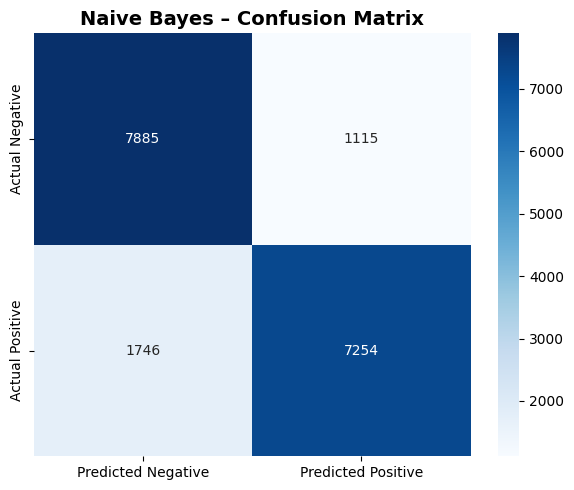

Saved as nb_confusion_matrix.png


In [ ]:
##########################################################
#                 8. CONFUSION MATRIX
#
# A confusion matrix shows the breakdown of correct
# and incorrect predictions across both classes:
#
#   True Negative  (TN): Correctly predicted negative
#   False Positive (FP): Incorrectly predicted positive
#   False Negative (FN): Incorrectly predicted negative
#   True Positive  (TP): Correctly predicted positive
#
# Saved as nb_confusion_matrix.png for the report.
# This plot is produced identically across all three
# model notebooks for visual consistency.
##########################################################
cm = confusion_matrix(y_test_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative', 'Actual Positive']
)
plt.title('Naive Bayes – Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nb_confusion_matrix.png', dpi=150)
plt.show()
print('Saved as nb_confusion_matrix.png')

## 9. Top Predictive Words
Shows which words the model considers most indicative of each sentiment class.

In [ ]:
##########################################################
#              9. TOP PREDICTIVE FEATURES
#
# One of Naive Bayes' key advantages over LSTM and BERT
# is interpretability — we can directly inspect which
# words the model finds most discriminative for each
# sentiment class.
#
# feature_log_prob_ contains the log probability of
# each feature (word/bigram) given each class:
#
#   log_probs[0] → log P(word | Negative)
#   log_probs[1] → log P(word | Positive)
#
# The words with the highest log probability for each
# class are the most strongly associated with that
# sentiment. These results are included in the report
# to validate that the model has learned meaningful
# sentiment associations rather than spurious patterns.
##########################################################
eature_names = tfidf.get_feature_names_out()
log_probs = nb_model.feature_log_prob_   # shape: (2, n_features)

# Top 15 words per class
top_n = 15
top_neg_idx = np.argsort(log_probs[0])[-top_n:][::-1]
top_pos_idx = np.argsort(log_probs[1])[-top_n:][::-1]

print('Top 15 words → NEGATIVE reviews:')
print([feature_names[i] for i in top_neg_idx])
print()
print('Top 15 words → POSITIVE reviews:')
print([feature_names[i] for i in top_pos_idx])

Top 15 words → NEGATIVE reviews:
['game', 'play', 'like', 'get', 'bore', 'dont', 'time', 'crash', 'cant', 'good', 'even', 'bad', 'make', 'realli', 'fun']

Top 15 words → POSITIVE reviews:
['game', 'good', 'great', 'fun', 'play', 'best', 'great game', 'love', 'one', 'stori', 'like', 'time', 'cool', 'ever', 'realli']


## 10. Save Results to CSV

In [ ]:
##########################################################
#                   10. SAVE RESULTS
#
# Two output files are produced:
#
#   nb_predictions.csv
#     Full prediction output: review_id,
#     predicted_sentiment, and true_sentiment
#     for every review in the test set.
#
#   nb_metrics.csv
#     Summary metrics for this model. Formatted
#     identically to the output of the LSTM and
#     BERT notebooks so all three can be combined
#     into a single comparison table in the report.
##########################################################
results_df.to_csv('nb_predictions.csv', index=False, encoding='utf-8-sig')
print('Predictions saved to nb_predictions.csv')

# Summary metrics saved for report
metrics_df = pd.DataFrame([{
    'Model': 'Naive Bayes',
    'Accuracy': round(acc, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1_Score': round(f1, 4),
    'Train_Time_s': round(training_time, 2),
    'Inference_Time_s': round(inference_time, 2)
}])
metrics_df.to_csv('nb_metrics.csv', index=False)
print('Metrics saved to nb_metrics.csv')
metrics_df

Predictions saved to nb_predictions.csv
Metrics saved to nb_metrics.csv


,Model,Accuracy,Precision,Recall,F1_Score,Train_Time_s,Inference_Time_s
0,Naive Bayes,0.8411,0.8668,0.806,0.8353,0.03,0.01


---
# ══════════════════════════════════════════════════════
# SECTION: LSTM
# ══════════════════════════════════════════════════════

# COMP316 – LSTM Sentiment Classifier
**Steam Reviews Dataset**


## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path to wherever you put the CSV files in your Drive
DATA_PATH = '/content/drive/MyDrive/COMP316_Project_CleanedData'

Mounted at /content/drive


## 2. Install & Import

In [ ]:
!pip install nltk tensorflow pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import re
import time
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense,
    Dropout, SpatialDropout1D, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from nltk.corpus import stopwords
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

nltk.download('stopwords', quiet=True)

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)
print('All imports successful.')

TensorFlow version: 2.20.0
GPU available: True
All imports successful.


## 3. Load Data

In [ ]:
train_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_train_FINAL.csv', encoding='utf-8-sig')
test_no_sent_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_test_NO_SENTIMENT_FINAL.csv', encoding='utf-8-sig')
test_with_sent_df = pd.read_csv(f'/content/drive/MyDrive/COMP316_Project_CleanedData/steam_reviews_test_WITH_SENTIMENT_FINAL.csv', encoding='utf-8-sig')

print('Train shape:', train_df.shape)
print('Test (no sentiment) shape:', test_no_sent_df.shape)
print('Test (with sentiment) shape:', test_with_sent_df.shape)
print()
print('Sentiment distribution in train:')
print(train_df['sentiment'].value_counts())
train_df.head(3)

Train shape: (42000, 5)
Test (no sentiment) shape: (18000, 4)
Test (with sentiment) shape: (18000, 5)

Sentiment distribution in train:
sentiment
1    21000
0    21000
Name: count, dtype: int64


,review_id,app_id,review_text,sentiment,helpful_score
0,1,4000,I remember watching so much content based arou...,1,0.50000
1,2,489830,"man i love this game, i grew up with it (i did...",0,0.50000
2,3,8870,You know the storyline is marvelous when you w...,1,0.52381


## 4. Text Preprocessing
Light cleaning only — LSTM benefits from word order so we don't stem.

In [ ]:
stop_words = set(stopwords.words('english'))
# Keep negations — they're crucial for sentiment
negations = {'not', 'no', 'nor', 'never', "don't", "doesn't", "didn't",
             "won't", "wouldn't", "can't", "couldn't", "shouldn't",
             "isn't", "aren't", "wasn't", "weren't", "hasn't", "haven't"}
stop_words = stop_words - negations

def preprocess(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

print('Preprocessing training data...')
start = time.time()
train_df['clean_text'] = train_df['review_text'].apply(preprocess)
print(f'Done in {time.time()-start:.1f}s')

print('Preprocessing test data...')
start = time.time()
test_no_sent_df['clean_text'] = test_no_sent_df['review_text'].apply(preprocess)
print(f'Done in {time.time()-start:.1f}s')

# Drop empty reviews after preprocessing
before = len(train_df)
train_df = train_df[train_df['clean_text'].str.len() > 0].reset_index(drop=True)
print(f'\nDropped {before - len(train_df)} empty training reviews after preprocessing')

print('\nSample before/after:')
print('BEFORE:', train_df['review_text'].iloc[0][:200])
print('AFTER: ', train_df['clean_text'].iloc[0][:200])

# Quick stats on review lengths
lengths = train_df['clean_text'].str.split().str.len()
print(f'\nReview length stats:')
print(f'  Mean:   {lengths.mean():.1f} tokens')
print(f'  Median: {lengths.median():.0f} tokens')
print(f'  90th %: {lengths.quantile(0.9):.0f} tokens')
print(f'  Max:    {lengths.max()} tokens')

Preprocessing training data...
Done in 2.6s
Preprocessing test data...
Done in 1.5s

Dropped 54 empty training reviews after preprocessing

Sample before/after:
BEFORE: I remember watching so much content based around this game throughout my childhood and wishing how I could get my hands on it as a kid...And buying it now in 2026?

I don't regret buying this game, 
AFTER:  remember watching much content based around game throughout childhood wishing could get hands kid buying regret buying game funny wholesome moments play friends addons get marketplace also make much b

Review length stats:
  Mean:   26.7 tokens
  Median: 10 tokens
  90th %: 63 tokens
  Max:    933 tokens


## 5. Tokenization & Padding

In [ ]:
MAX_VOCAB = 30000   # vocabulary size
MAX_LEN   = 150     # most reviews fit comfortably in 150 tokens

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

actual_vocab = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f'Total unique words found: {len(tokenizer.word_index):,}')
print(f'Using vocab size: {actual_vocab:,}')

X_train = pad_sequences(
    tokenizer.texts_to_sequences(train_df['clean_text']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test = pad_sequences(
    tokenizer.texts_to_sequences(test_no_sent_df['clean_text']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)

y_train = train_df['sentiment'].values.astype('float32')
y_test_true = test_with_sent_df.set_index('review_id').loc[test_no_sent_df['review_id']]['sentiment'].values

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train balance: {np.bincount(y_train.astype(int))}')

Total unique words found: 36,129
Using vocab size: 30,000

X_train shape: (41946, 150)
X_test shape:  (18000, 150)
y_train balance: [20981 20965]


In [ ]:
EMBED_DIM  = 128
LSTM_UNITS = 64

model = Sequential([
    tf.keras.Input(shape=(MAX_LEN,)),
    Embedding(input_dim=actual_vocab, output_dim=EMBED_DIM, mask_zero=False),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=1e-3, clipnorm=1.0)

model.compile(
    loss='binary_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 150, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,947,137 (15.06 MB)

 Trainable params: 3,947,137 (15.06 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=1,
    min_lr=1e-6, verbose=1
)

print('Training Bidirectional LSTM...')
start = time.time()

history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

training_time = time.time() - start
print(f'\nTraining complete in {training_time:.1f}s ({training_time/60:.1f} min)')

Training Bidirectional LSTM...
Epoch 1/8
295/295 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7883 - loss: 0.4454 - val_accuracy: 0.8458 - val_loss: 0.3629 - learning_rate: 0.0010
Epoch 2/8
294/295 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8654 - loss: 0.3223
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8763 - loss: 0.3030 - val_accuracy: 0.8482 - val_loss: 0.3661 - learning_rate: 0.0010
Epoch 3/8
293/295 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8997 - loss: 0.2523
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
295/295 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9117 - loss: 0.2295 - val_accuracy: 0.8474 - val_loss: 0.3879 - learning_rate: 5.0000e-04
Epoch 4/8
295/295 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9207 - loss: 0.2126
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step 

## 8. Training History Plot

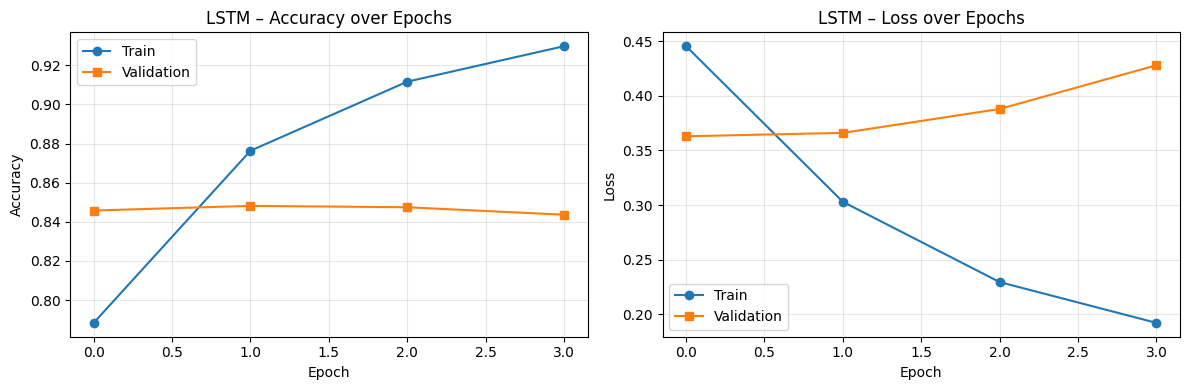

Saved as lstm_training_history.png


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], marker='o', label='Train')
ax1.plot(history.history['val_accuracy'], marker='s', label='Validation')
ax1.set_title('LSTM – Accuracy over Epochs')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'], marker='o', label='Train')
ax2.plot(history.history['val_loss'], marker='s', label='Validation')
ax2.set_title('LSTM – Loss over Epochs')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150)
plt.show()
print('Saved as lstm_training_history.png')

## 9. Predict on Test Set

In [ ]:
print('Generating predictions...')
start = time.time()
y_prob = model.predict(X_test, batch_size=256, verbose=1)
y_pred = (y_prob >= 0.5).astype(int).flatten()
inference_time = time.time() - start
print(f'Inference complete in {inference_time:.2f}s')

results_df = test_no_sent_df[['review_id']].copy()
results_df['predicted_sentiment'] = y_pred
results_df['true_sentiment'] = y_test_true
print('\nPrediction distribution:')
print(pd.Series(y_pred).value_counts())
results_df.head(10)

Generating predictions...
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Inference complete in 1.05s

Prediction distribution:
0    9481
1    8519
Name: count, dtype: int64


,review_id,predicted_sentiment,true_sentiment
0,1,0,0
1,2,1,1
2,3,1,1
3,4,0,0
4,5,0,0
5,6,1,1
6,7,1,1
7,8,0,0
8,9,1,1
9,10,1,1


## 10. Evaluate the Model

In [ ]:
acc       = accuracy_score(y_test_true, y_pred)
precision = precision_score(y_test_true, y_pred)
recall    = recall_score(y_test_true, y_pred)
f1        = f1_score(y_test_true, y_pred)

print('='*45)
print('        LSTM EVALUATION RESULTS')
print('='*45)
print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision: {precision:.4f}')
print(f'  Recall   : {recall:.4f}')
print(f'  F1-Score : {f1:.4f}')
print(f'  Train Time: {training_time:.1f}s ({training_time/60:.1f} min)')
print(f'  Inference: {inference_time:.2f}s ({len(y_pred)} reviews)')
print('='*45)
print()
print('Full Classification Report:')
print(classification_report(y_test_true, y_pred, target_names=['Negative (0)', 'Positive (1)']))

        LSTM EVALUATION RESULTS
  Accuracy : 0.8405  (84.05%)
  Precision: 0.8597
  Recall   : 0.8138
  F1-Score : 0.8361
  Train Time: 35.0s (0.6 min)
  Inference: 1.05s (18000 reviews)

Full Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.82      0.87      0.84      9000
Positive (1)       0.86      0.81      0.84      9000

    accuracy                           0.84     18000
   macro avg       0.84      0.84      0.84     18000
weighted avg       0.84      0.84      0.84     18000



## 11. Confusion Matrix

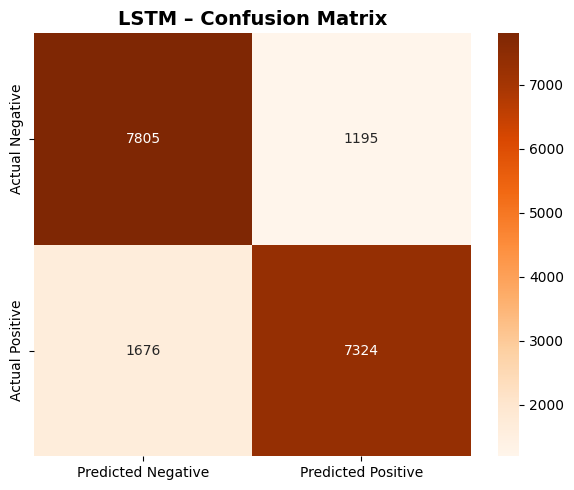

Saved as lstm_confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative', 'Actual Positive']
)
plt.title('LSTM – Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', dpi=150)
plt.show()
print('Saved as lstm_confusion_matrix.png')

## 12. Save Results

In [ ]:
results_df.to_csv('lstm_predictions.csv', index=False, encoding='utf-8-sig')
print('Predictions saved to lstm_predictions.csv')

metrics_df = pd.DataFrame([{
    'Model': 'LSTM',
    'Accuracy': round(acc, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'F1_Score': round(f1, 4),
    'Train_Time_s': round(training_time, 2),
    'Inference_Time_s': round(inference_time, 2)
}])
metrics_df.to_csv('lstm_metrics.csv', index=False)
print('Metrics saved to lstm_metrics.csv')
metrics_df

Predictions saved to lstm_predictions.csv
Metrics saved to lstm_metrics.csv


,Model,Accuracy,Precision,Recall,F1_Score,Train_Time_s,Inference_Time_s
0,LSTM,0.8405,0.8597,0.8138,0.8361,35.04,1.05


---
# ══════════════════════════════════════════════════════
# SECTION: BERT
# ══════════════════════════════════════════════════════

# COMP316 – BERT Sentiment Classifier
**Steam Reviews Dataset**

> ⚠️ **Requires NVIDIA GPU with CUDA support.**
>
> This notebook is configured for local execution on a CUDA-enabled GPU (e.g. GTX 1060 6GB).
> It is NOT configured for Google Colab. Do not attempt to run on CPU — training time would
> be prohibitively long (10+ hours vs ~2-3 hours on GPU).
>
> **Before running, verify your environment:**
> ```
> pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
> pip install transformers pandas matplotlib seaborn scikit-learn
> ```
>
> ⚠️ **BERT is large and slow — expect ~2–3 hours training time on a GTX 1060.**

##########################################################
#                 BERT SENTIMENT CLASSIFIER
#                   COMP316 PROJECT
#
# Model:   bert-base-uncased (HuggingFace Transformers)
# Task:    Binary sentiment classification
#          (1 = Positive, 0 = Negative)
#
# Dataset: Steam Reviews
#          - Training:  42,000 reviews (balanced 50/50)
#          - Test:      18,000 reviews (balanced 50/50)
#
# Hardware: Designed for local GPU execution
#           Tested on NVIDIA GTX 1060 6GB (CUDA 11.8)
# This decision was made because of the limitation of
# Google Collab since it would not allow us to
# train on the full 42k. This would invalidate
# out results as it would mean that our BERT
# models was not fairly train on the same
# data as the other 2
#
# This notebook is one of three models evaluated:
#   1. Naive Bayes  (Traditional ML)
#   2. LSTM         (Deep Learning)
#   3. BERT         (Transformer) ← This notebook
#
# All three models use identical train/test splits
# to ensure fair and consistent comparison.
##########################################################

##########################################################
#                 BERT MODEL OVERVIEW
#
# BERT (Bidirectional Encoder Representations from
# Transformers) is a transformer-based language model
# developed by Google (Devlin et al., 2018).
#
# KEY PROPERTIES:
#
# - Bidirectional: reads text left-to-right AND
#   right-to-left simultaneously, capturing full
#   sentence context for each token
#
# - Pre-trained: bert-base-uncased was trained on
#   BooksCorpus + English Wikipedia (3.3B words)
#   using Masked Language Modelling (MLM) and
#   Next Sentence Prediction (NSP)
#
# - Fine-tuned: we adapt the pre-trained weights
#   to our specific sentiment classification task
#   using our Steam review dataset
#
# WHY bert-base-uncased:
#
# - Lowercases all input text automatically
#   (appropriate for informal Steam reviews)
# - Smaller than bert-large (110M vs 340M parameters)
#   making it feasible on consumer GPU hardware
# - Well-established baseline for NLP benchmarks
#
# ARCHITECTURE:
# - 12 transformer layers
# - 12 attention heads
# - 768 hidden dimensions
# - 110M total parameters
##########################################################

## 1. Imports

In [1]:
##########################################################
#                      1. IMPORTS
#
# Core libraries:
#   pandas        → data loading and manipulation
#   numpy         → numerical operations
#   time          → training duration tracking
#   matplotlib    → training history plots
#   seaborn       → confusion matrix visualisation
#
# PyTorch:
#   torch                    → tensor operations + CUDA
#   torch.utils.data         → Dataset and DataLoader
#   torch.optim.AdamW        → optimiser (standard for BERT)
#
# HuggingFace Transformers:
#   BertTokenizer                  → WordPiece tokenisation
#   BertForSequenceClassification  → pre-trained BERT +
#                                    classification head
#   get_linear_schedule_with_warmup → LR scheduler
#
# Scikit-learn:
#   accuracy_score etc → evaluation metrics
##########################################################

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

print('All imports successful.')

All imports successful.


## 2. GPU Verification

In [2]:
##########################################################
#                   2. GPU VERIFICATION
#
# BERT fine-tuning requires a CUDA-enabled GPU.
# Running on CPU is technically possible but would
# take 10+ hours for 42k reviews — not practical.
#
# This block raises an explicit error if CUDA is not
# detected, rather than silently falling back to CPU
# and producing an unusably slow training run.
#
# If this fails, check:
#   1. PyTorch was installed with CUDA support:
#      pip install torch --index-url
#      https://download.pytorch.org/whl/cu118
#   2. NVIDIA drivers are up to date
#   3. Run: nvidia-smi in terminal to verify GPU
##########################################################

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA not detected. Ensure PyTorch is installed with CUDA support.\n"
        "Run: pip install torch --index-url https://download.pytorch.org/whl/cu118"
    )

device = torch.device('cuda')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Using device: {device}')

CUDA available: True
GPU: NVIDIA GeForce GTX 1060
VRAM: 6.4 GB
Using device: cuda


## 3. Configuration

In [3]:
##########################################################
#                   3. CONFIGURATION
#
# DATA PATHS:
#   Update DATA_PATH to the folder containing your
#   cleaned CSV files produced by the preprocessing
#   pipeline. All three model notebooks must point
#   to the same files for a fair comparison.
#
# MODEL PARAMETERS:
#
#   MODEL_NAME = 'bert-base-uncased'
#     Lowercased variant — appropriate for informal
#     Steam reviews where casing is inconsistent.
#
#   MAX_LEN = 128
#     BERT supports up to 512 tokens, but 128 is
#     sufficient for Steam reviews (typically short)
#     and significantly reduces memory usage and
#     training time. Sequences longer than 128 tokens
#     are truncated; shorter sequences are padded.
#
#   BATCH_SIZE = 8
#     Reduced from the standard 16 to fit within the
#     6GB VRAM of the GTX 1060. Each batch of 8
#     reviews is tokenised to MAX_LEN=128 and processed
#     in a single forward/backward pass. Increase to
#     16 only if running on a GPU with 8GB+ VRAM.
#
#   EPOCHS = 3
#     Standard for BERT fine-tuning. The original
#     BERT paper (Devlin et al.) recommends 2-4 epochs
#     for downstream classification tasks. More epochs
#     risk overfitting the pre-trained representations.
#
#   LEARNING_RATE = 2e-5
#     Canonical BERT fine-tuning rate. Higher rates
#     destabilise the pre-trained weights; lower rates
#     slow convergence. 2e-5 is the most widely used
#     value in the literature for classification tasks.
##########################################################

# ========== DATA PATHS ==========
# Update this to the folder containing your CSV files
DATA_PATH = r"C:\Users\Israfeel Yusuf\Documents\COMP316\data"

TRAIN_FILE         = f'{DATA_PATH}/steam_reviews_train.csv'
TEST_NO_SENT_FILE  = f'{DATA_PATH}/steam_reviews_test_NO_SENTIMENT.csv'
TEST_WITH_SENT_FILE= f'{DATA_PATH}/steam_reviews_test_WITH_SENTIMENT.csv'

# ========== MODEL PARAMETERS ==========
MODEL_NAME    = 'bert-base-uncased'
MAX_LEN       = 128
BATCH_SIZE    = 8
EPOCHS        = 3
LEARNING_RATE = 2e-5

print('Configuration loaded.')
print(f'  Model:       {MODEL_NAME}')
print(f'  Max length:  {MAX_LEN} tokens')
print(f'  Batch size:  {BATCH_SIZE}')
print(f'  Epochs:      {EPOCHS}')
print(f'  Learing rate:{LEARNING_RATE}')

Configuration loaded.
  Model:       bert-base-uncased
  Max length:  128 tokens
  Batch size:  8
  Epochs:      3
  Learing rate:2e-05


## 4. Load Data

In [4]:
##########################################################
#                     4. LOAD DATA
#
# Three files are loaded:
#
#   steam_reviews_train_FINAL.csv
#     42,000 reviews with sentiment labels (0 or 1).
#     Used for fine-tuning BERT weights.
#     Balanced: 21,000 positive, 21,000 negative.
#
#   steam_reviews_test_NO_SENTIMENT_FINAL.csv
#     18,000 reviews WITHOUT sentiment labels.
#     Used as input for generating predictions.
#     BERT sees only the review text.
#
#   steam_reviews_test_WITH_SENTIMENT_FINAL.csv
#     18,000 reviews WITH sentiment labels.
#     Used to evaluate prediction accuracy AFTER
#     predictions have been generated.
#     Never exposed to the model during inference.
#
# NOTE ON CONSISTENCY:
#   No subsampling is applied here. BERT trains and
#   evaluates on the full dataset, identical to the
#   Naive Bayes and LSTM notebooks. This ensures
#   all three models are compared on equal footing.
##########################################################

steam_reviews_train_FINAL = r"C:\Users\Israfeel Yusuf\Documents\COMP316\data\steam_reviews_train_FINAL.csv"

steam_reviews_test_NO_SENTIMENT_FINAL = r"C:\Users\Israfeel Yusuf\Documents\COMP316\data\steam_reviews_test_NO_SENTIMENT_FINAL.csv"

steam_reviews_test_WITH_SENTIMENT_FINAL = r"C:\Users\Israfeel Yusuf\Documents\COMP316\data\steam_reviews_test_WITH_SENTIMENT_FINAL.csv"

train_df = pd.read_csv(
    steam_reviews_train_FINAL,
    encoding='utf-8-sig'
)

test_no_sent_df = pd.read_csv(
    steam_reviews_test_NO_SENTIMENT_FINAL,
    encoding='utf-8-sig'
)

test_with_sent_df = pd.read_csv(
    steam_reviews_test_WITH_SENTIMENT_FINAL,
    encoding='utf-8-sig'
)

print('=== DATA LOADED ===')
print(f'Training set:  {len(train_df):,} reviews')
print(f'Test set:      {len(test_no_sent_df):,} reviews')

print()
print('Training sentiment distribution:')
print(train_df['sentiment'].value_counts())

print()
print('Test (with sentiment) distribution:')
print(test_with_sent_df['sentiment'].value_counts())

=== DATA LOADED ===
Training set:  42,000 reviews
Test set:      18,000 reviews

Training sentiment distribution:
sentiment
1    21000
0    21000
Name: count, dtype: int64

Test (with sentiment) distribution:
sentiment
0    9000
1    9000
Name: count, dtype: int64


## 5. Tokenise with BERT Tokenizer

In [5]:
##########################################################
#               5. TOKENISE WITH BERT TOKENIZER
#
# BERT uses WordPiece tokenisation — it splits words
# into subword units (e.g. 'playing' → 'play', '##ing')
# which allows it to handle unknown words gracefully.
#
# Unlike Naive Bayes and LSTM, BERT does NOT require
# manual text cleaning (lowercasing, stopword removal,
# stemming). The tokeniser and pre-trained weights
# handle this implicitly.
#
# TOKENISATION PARAMETERS:
#
#   max_length=MAX_LEN
#     Truncates reviews longer than 128 tokens.
#     Steam reviews are typically short, so very
#     little information is lost.
#
#   padding='max_length'
#     Pads shorter reviews with [PAD] tokens to
#     ensure uniform tensor dimensions within a batch.
#
#   truncation=True
#     Enables truncation for reviews exceeding MAX_LEN.
#
#   attention_mask
#     A binary mask (1 = real token, 0 = padding).
#     Tells BERT which tokens to attend to and which
#     to ignore, preventing padding from influencing
#     the model's representations.
#
# SteamReviewDataset:
#   A custom PyTorch Dataset class that tokenises
#   reviews on-the-fly during DataLoader iteration.
#   Labels are optional — the test dataset has none
#   at inference time.
##########################################################

print(f'Loading {MODEL_NAME} tokenizer...')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded.')


class SteamReviewDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Guard against None or NaN review text
        text = str(self.texts[idx]) if self.texts[idx] is not None else ''

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze()
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# =========================
# BUILD DATASETS
# =========================
train_dataset = SteamReviewDataset(
    texts=train_df['review_text'].tolist(),
    labels=train_df['sentiment'].tolist(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)
test_dataset = SteamReviewDataset(
    texts=test_no_sent_df['review_text'].tolist(),
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

# =========================
# BUILD DATALOADERS
# =========================
# shuffle=True for training ensures the model does not
# learn the order of the data across epochs.
# shuffle=False for testing ensures predictions align
# with the original row order for evaluation.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader):,}  ({len(train_dataset):,} reviews @ batch size {BATCH_SIZE})')
print(f'Test  batches: {len(test_loader):,}  ({len(test_dataset):,} reviews @ batch size {BATCH_SIZE})')

Loading bert-base-uncased tokenizer...


Tokenizer loaded.
Train batches: 5,250  (42,000 reviews @ batch size 8)
Test  batches: 2,250  (18,000 reviews @ batch size 8)


## 6. Load Pre-trained BERT Model

In [6]:
##########################################################
#             6. LOAD PRE-TRAINED BERT MODEL
#
# BertForSequenceClassification loads the pre-trained
# bert-base-uncased weights and attaches a linear
# classification head on top of the [CLS] token output.
#
# The [CLS] token is a special token prepended to every
# input sequence. After passing through all 12 transformer
# layers, its final hidden state is used as the aggregate
# sequence representation for classification.
#
# num_labels=2 configures the head for binary output:
#   - Output 0 → Negative sentiment
#   - Output 1 → Positive sentiment
#
# The model is moved to the GPU immediately after loading
# to ensure all forward passes occur on CUDA.
##########################################################

print(f'Loading {MODEL_NAME} for sequence classification...')
bert_model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
bert_model = bert_model.to(device)
print(f'Model loaded and moved to: {device}')
print(f'Total parameters: {sum(p.numel() for p in bert_model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in bert_model.parameters() if p.requires_grad):,}')

Loading bert-base-uncased for sequence classification...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded and moved to: cuda
Total parameters: 109,483,778
Trainable parameters: 109,483,778


## 7. Fine-tune BERT

In [7]:
##########################################################
#                   7. FINE-TUNE BERT
#
# OPTIMISER — AdamW:
#   Adam with decoupled weight decay (AdamW) is the
#   standard optimiser for transformer fine-tuning.
#   eps=1e-8 improves numerical stability in the
#   Adam denominator.
#
# LEARNING RATE SCHEDULER — Linear Warmup:
#   The learning rate starts at 0, linearly increases
#   to LEARNING_RATE over the warmup steps (first 10%
#   of training), then linearly decays back to 0.
#
#   Warmup prevents large gradient updates from
#   destabilising pre-trained BERT weights in the
#   early stages of fine-tuning.
#
# GRADIENT CLIPPING (clip_grad_norm_, max=1.0):
#   Caps the norm of the gradient vector at 1.0.
#   This prevents exploding gradients — a known
#   instability risk when fine-tuning large transformer
#   models on small datasets.
#
# VALIDATION SPLIT:
#   10% of training data (4,200 reviews) is held out
#   as a validation set. Validation loss is computed
#   after each epoch. The checkpoint with the lowest
#   validation loss is restored after training,
#   consistent with the EarlyStopping behaviour
#   applied to the BiLSTM.
#
# TRAINING LOOP:
#   For each batch:
#     1. Zero gradients from previous step
#     2. Forward pass → compute loss + logits
#     3. Backward pass → compute gradients
#     4. Clip gradients
#     5. Update weights (optimiser step)
#     6. Update learning rate (scheduler step)
#
# PROGRESS LOGGING:
#   Loss and accuracy are printed every 200 batches
#   so you can monitor training without waiting for
#   a full epoch to complete.
##########################################################

from sklearn.model_selection import train_test_split
import copy

# =========================
# VALIDATION SPLIT
# =========================
# Hold out 10% of training data (stratified) as a
# validation set for checkpoint selection.
# This mirrors the EarlyStopping setup used for the BiLSTM.
train_texts_full   = train_df['review_text'].tolist()
train_labels_full  = train_df['sentiment'].tolist()

train_texts, val_texts, train_labels_split, val_labels_split = train_test_split(
    train_texts_full,
    train_labels_full,
    test_size=0.1,
    stratify=train_labels_full,
    random_state=42
)

print(f'Training samples:   {len(train_texts):,}')
print(f'Validation samples: {len(val_texts):,}')

# =========================
# BUILD DATASETS
# =========================
train_dataset_split = SteamReviewDataset(
    texts=train_texts,
    labels=train_labels_split,
    tokenizer=tokenizer,
    max_len=MAX_LEN
)
val_dataset = SteamReviewDataset(
    texts=val_texts,
    labels=val_labels_split,
    tokenizer=tokenizer,
    max_len=MAX_LEN
)

train_loader_split = DataLoader(train_dataset_split, batch_size=BATCH_SIZE, shuffle=True)
val_loader         = DataLoader(val_dataset,         batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader_split):,}')
print(f'Val   batches: {len(val_loader):,}')

# =========================
# OPTIMISER AND SCHEDULER
# =========================
optimizer   = AdamW(bert_model.parameters(), lr=LEARNING_RATE, eps=1e-8)
total_steps = len(train_loader_split) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

train_losses = []
train_accs   = []
val_losses   = []
val_accs     = []

best_val_loss    = float('inf')
best_model_state = None

print(f'Fine-tuning BERT for {EPOCHS} epochs...')
print(f'Total training steps: {total_steps:,}')
print(f'Warmup steps: {int(0.1 * total_steps):,}')
print()

total_start = time.time()

for epoch in range(EPOCHS):
    # ---- TRAINING ----
    bert_model.train()
    epoch_loss  = 0
    correct     = 0
    total       = 0
    epoch_start = time.time()

    for i, batch in enumerate(train_loader_split):
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss   = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        preds       = torch.argmax(logits, dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (i + 1) % 200 == 0:
            running_acc = correct / total
            print(f'  Epoch {epoch+1} | Batch {i+1}/{len(train_loader_split)} | '
                  f'Loss: {loss.item():.4f} | Running Acc: {running_acc:.4f}')

    avg_train_loss = epoch_loss / len(train_loader_split)
    train_acc      = correct / total
    train_losses.append(avg_train_loss)
    train_accs.append(train_acc)

    # ---- VALIDATION ----
    bert_model.eval()
    val_loss    = 0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            val_loss    += outputs.loss.item()
            preds        = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc_ep   = val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accs.append(val_acc_ep)

    epoch_time = time.time() - epoch_start
    print(f'Epoch {epoch+1}/{EPOCHS} — '
          f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | '
          f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc_ep:.4f} | '
          f'Time: {epoch_time:.0f}s ({epoch_time/60:.1f} min)')

    # ---- CHECKPOINT BEST MODEL ----
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        best_model_state = copy.deepcopy(bert_model.state_dict())
        print(f'  ✓ New best model saved (val_loss={best_val_loss:.4f})')

training_time = time.time() - total_start

# =========================
# RESTORE BEST WEIGHTS
# =========================
bert_model.load_state_dict(best_model_state)
print(f'\nBest model restored (val_loss={best_val_loss:.4f})')
print(f'Total training time: {training_time:.1f}s ({training_time/60:.1f} min)')

Training samples:   37,800
Validation samples: 4,200
Train batches: 4,725
Val   batches: 525
Fine-tuning BERT for 3 epochs...
Total training steps: 14,175
Warmup steps: 1,417

  Epoch 1 | Batch 200/4725 | Loss: 0.6702 | Running Acc: 0.5869
  Epoch 1 | Batch 400/4725 | Loss: 0.4067 | Running Acc: 0.6744
  Epoch 1 | Batch 600/4725 | Loss: 0.7993 | Running Acc: 0.7294
  Epoch 1 | Batch 800/4725 | Loss: 0.3271 | Running Acc: 0.7559
  Epoch 1 | Batch 1000/4725 | Loss: 0.1972 | Running Acc: 0.7760
  Epoch 1 | Batch 1200/4725 | Loss: 0.0913 | Running Acc: 0.7900
  Epoch 1 | Batch 1400/4725 | Loss: 0.2894 | Running Acc: 0.7987
  Epoch 1 | Batch 1600/4725 | Loss: 0.2257 | Running Acc: 0.8080
  Epoch 1 | Batch 1800/4725 | Loss: 0.9142 | Running Acc: 0.8140
  Epoch 1 | Batch 2000/4725 | Loss: 0.8548 | Running Acc: 0.8194
  Epoch 1 | Batch 2200/4725 | Loss: 0.4610 | Running Acc: 0.8249
  Epoch 1 | Batch 2400/4725 | Loss: 0.0324 | Running Acc: 0.8276
  Epoch 1 | Batch 2600/4725 | Loss: 0.2632 | Run

## 8. Save Model

In [8]:
##########################################################
#                    8. SAVE MODEL
#
# The fine-tuned model and tokeniser are saved to disk
# immediately after training completes.
#
# WHY THIS IS IMPORTANT:
#   BERT training takes 2-3 hours on a GTX 1060.
#   Saving ensures the trained weights are not lost
#   if the kernel restarts or the session ends before
#   inference and evaluation are complete.
#
# The saved model can be reloaded with:
#   BertForSequenceClassification.from_pretrained(
#       './bert_steam_model'
#   )
##########################################################

SAVE_DIR = './bert_steam_model'
bert_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f'Model and tokenizer saved to: {SAVE_DIR}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ./bert_steam_model


## 9. Training History Plot

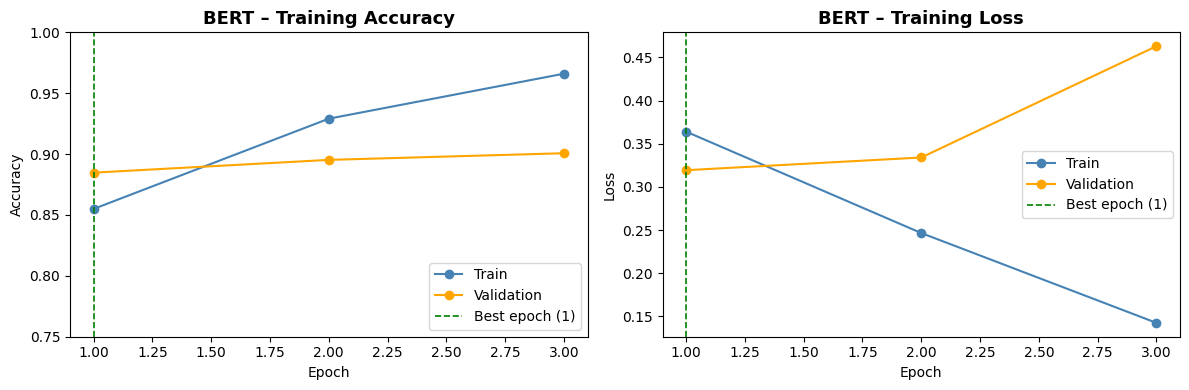

Saved: bert_training_history.png
Best epoch: 1 (val_loss=0.3194)


In [9]:
##########################################################
#               9. TRAINING HISTORY PLOT
#
# Plots training AND validation accuracy and loss
# across epochs.
#
# WHAT TO LOOK FOR:
#   - Training accuracy should increase each epoch
#   - Validation accuracy should follow; a growing gap
#     between train and val indicates overfitting
#   - The epoch with the lowest validation loss is the
#     checkpoint that was restored after training
#
# Saved as bert_training_history.png for inclusion
# in the project report.
##########################################################

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)

# --- Accuracy plot ---
ax1.plot(epochs_range, train_accs, marker='o', color='steelblue', label='Train')
ax1.plot(epochs_range, val_accs,   marker='o', color='orange',    label='Validation')
ax1.set_title('BERT – Training Accuracy', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.75, 1.0)
ax1.legend()

# Mark best epoch (lowest val loss)
best_epoch = val_losses.index(min(val_losses)) + 1
ax1.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.2,
            label=f'Best epoch ({best_epoch})')
ax1.legend()

# --- Loss plot ---
ax2.plot(epochs_range, train_losses, marker='o', color='steelblue', label='Train')
ax2.plot(epochs_range, val_losses,   marker='o', color='orange',    label='Validation')
ax2.set_title('BERT – Training Loss', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.2,
            label=f'Best epoch ({best_epoch})')
ax2.legend()

plt.tight_layout()
plt.savefig('bert_training_history.png', dpi=150)
plt.show()
print(f'Saved: bert_training_history.png')
print(f'Best epoch: {best_epoch} (val_loss={min(val_losses):.4f})')

## 10. Predict on Test Set

In [10]:
##########################################################
#               10. PREDICT ON TEST SET
#
# Predictions are generated on the test set that
# contains NO sentiment labels (test_no_sent_df).
#
# The model only sees review_text — it has no access
# to the true labels during inference.
#
# torch.no_grad():
#   Disables gradient computation during inference.
#   This reduces memory usage and speeds up prediction
#   since we are not backpropagating.
#
# bert_model.eval():
#   Switches the model to evaluation mode, which
#   disables dropout layers that are only active
#   during training.
#
# TRUE LABEL ALIGNMENT:
#   After generating predictions, true labels are
#   retrieved from test_with_sent_df using review_id
#   to ensure correct row-by-row alignment.
#   This is robust to any ordering differences
#   between the two test files.
##########################################################

bert_model.eval()
all_preds = []

print('Generating predictions on test set...')
inference_start = time.time()

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

inference_time = time.time() - inference_start
y_pred = np.array(all_preds)
print(f'Inference complete: {len(y_pred):,} predictions in {inference_time:.2f}s')

# =========================
# ALIGN TRUE LABELS
# =========================
# Match ground truth to predictions using review_id
# to guarantee correct alignment regardless of file ordering
y_test_true = (
    test_with_sent_df
    .set_index('review_id')
    .loc[test_no_sent_df['review_id']]['sentiment']
    .values
)

# =========================
# BUILD RESULTS DATAFRAME
# =========================
results_df = test_no_sent_df[['review_id']].copy()
results_df['predicted_sentiment'] = y_pred
results_df['true_sentiment']      = y_test_true

print()
print('Sample predictions:')
print(results_df.head(10).to_string(index=False))

Generating predictions on test set...
Inference complete: 18,000 predictions in 230.95s

Sample predictions:
 review_id  predicted_sentiment  true_sentiment
         1                    0               0
         2                    1               1
         3                    1               1
         4                    0               0
         5                    0               0
         6                    1               1
         7                    1               1
         8                    0               0
         9                    1               1
        10                    1               1


## 11. Evaluate the Model

In [11]:
##########################################################
#                 11. EVALUATE THE MODEL
#
# METRICS USED (consistent across all three models):
#
#   Accuracy:
#     Proportion of correctly classified reviews.
#     Primary metric for balanced datasets.
#
#   Precision:
#     Of all reviews predicted positive, how many
#     actually were? Measures false positive rate.
#
#   Recall:
#     Of all actually positive reviews, how many
#     did the model correctly identify? Measures
#     false negative rate.
#
#   F1-Score:
#     Harmonic mean of precision and recall.
#     Most informative single metric for comparing
#     classification models.
#
# These four metrics are recorded for all three models
# (Naive Bayes, LSTM, BERT) in bert_metrics.csv,
# enabling direct side-by-side comparison in the report.
##########################################################

acc       = accuracy_score(y_test_true, y_pred)
precision = precision_score(y_test_true, y_pred)
recall    = recall_score(y_test_true, y_pred)
f1        = f1_score(y_test_true, y_pred)

print('=' * 50)
print('           BERT EVALUATION RESULTS')
print('=' * 50)
print(f'  Accuracy :    {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision:    {precision:.4f}')
print(f'  Recall   :    {recall:.4f}')
print(f'  F1-Score :    {f1:.4f}')
print(f'  Train Time:   {training_time:.1f}s ({training_time/60:.1f} min)')
print(f'  Inference:    {inference_time:.2f}s ({len(y_pred):,} reviews)')
print('=' * 50)
print()
print('Full Classification Report:')
print(classification_report(
    y_test_true, y_pred,
    target_names=['Negative (0)', 'Positive (1)']
))

           BERT EVALUATION RESULTS
  Accuracy :    0.8873  (88.73%)
  Precision:    0.8555
  Recall   :    0.9321
  F1-Score :    0.8922
  Train Time:   4818.5s (80.3 min)
  Inference:    230.95s (18,000 reviews)

Full Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.93      0.84      0.88      9000
Positive (1)       0.86      0.93      0.89      9000

    accuracy                           0.89     18000
   macro avg       0.89      0.89      0.89     18000
weighted avg       0.89      0.89      0.89     18000



## 12. Confusion Matrix

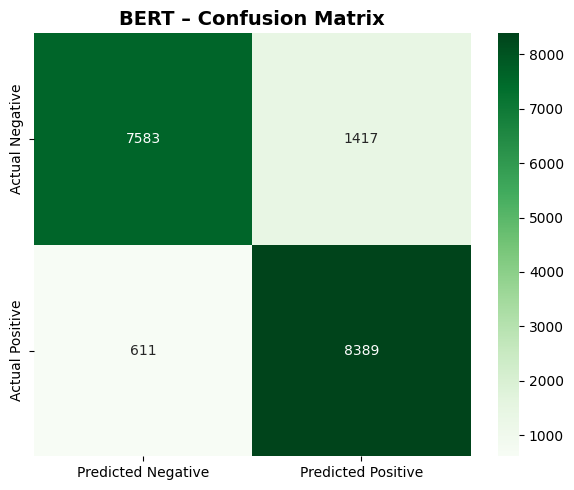

Saved: bert_confusion_matrix.png


In [12]:
##########################################################
#                 12. CONFUSION MATRIX
#
# A confusion matrix shows the breakdown of correct
# and incorrect predictions across both classes:
#
#   True Negative  (TN): Correctly predicted negative
#   False Positive (FP): Incorrectly predicted positive
#   False Negative (FN): Incorrectly predicted negative
#   True Positive  (TP): Correctly predicted positive
#
# Saved as bert_confusion_matrix.png for the report.
# This plot is produced identically across all three
# model notebooks for visual consistency.
##########################################################

cm = confusion_matrix(y_test_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=['Predicted Negative', 'Predicted Positive'],
    yticklabels=['Actual Negative',    'Actual Positive']
)
plt.title('BERT – Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: bert_confusion_matrix.png')

## 13. Save Results

In [13]:
##########################################################
#                   13. SAVE RESULTS
#
# Two output files are produced:
#
#   bert_predictions.csv
#     Full prediction output: review_id,
#     predicted_sentiment, and true_sentiment
#     for every review in the test set.
#
#   bert_metrics.csv
#     Summary metrics for this model. Formatted
#     identically to the output of the Naive Bayes
#     and LSTM notebooks so all three can be combined
#     into a single comparison table in the report.
##########################################################

# =========================
# SAVE PREDICTIONS
# =========================
results_df.to_csv('bert_predictions.csv', index=False, encoding='utf-8-sig')
print('Predictions saved: bert_predictions.csv')

# =========================
# SAVE METRICS
# =========================
metrics_df = pd.DataFrame([{
    'Model'            : 'BERT',
    'Accuracy'         : round(acc, 4),
    'Precision'        : round(precision, 4),
    'Recall'           : round(recall, 4),
    'F1_Score'         : round(f1, 4),
    'Train_Time_s'     : round(training_time, 2),
    'Inference_Time_s' : round(inference_time, 2),
    'Train_Samples'    : len(train_df),
    'Test_Samples'     : len(test_no_sent_df)
}])
metrics_df.to_csv('bert_metrics.csv', index=False)
print('Metrics saved:     bert_metrics.csv')
print()
print(metrics_df.to_string(index=False))

Predictions saved: bert_predictions.csv
Metrics saved:     bert_metrics.csv

Model  Accuracy  Precision  Recall  F1_Score  Train_Time_s  Inference_Time_s  Train_Samples  Test_Samples
 BERT    0.8873     0.8555  0.9321    0.8922       4818.55            230.95          42000         18000


In [14]:
import pandas as pd
from transformers import BertTokenizer

df = pd.read_csv(r'C:\Users\Israfeel Yusuf\Downloads\steam_reviews_clean_full.csv', encoding='utf-8-sig')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

lengths = df['review_text'].apply(lambda x: len(tokenizer.encode(str(x), add_special_tokens=True)))
print(lengths.describe())
print(f"Reviews under 128 tokens:  {(lengths <= 128).sum():,} ({(lengths <= 128).mean()*100:.1f}%)")
print(f"Reviews over 128 tokens:   {(lengths > 128).sum():,} ({(lengths > 128).mean()*100:.1f}%)")
print(f"Reviews over 256 tokens:   {(lengths > 256).sum():,} ({(lengths > 256).mean()*100:.1f}%)")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (691 > 512). Running this sequence through the model will result in indexing errors


count    60000.000000
mean        65.982917
std        127.768711
min          3.000000
25%         12.000000
50%         25.000000
75%         65.000000
max       2043.000000
Name: review_text, dtype: float64
Reviews under 128 tokens:  52,486 (87.5%)
Reviews over 128 tokens:   7,514 (12.5%)
Reviews over 256 tokens:   3,067 (5.1%)
